# BDD100K Grad-CAM Demo
Loads a small subset of BDD100K images and visualizes Grad-CAM overlays using a pre-trained ResNet.

In [5]:
import sys, os
PROJECT_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd())=='notebooks' else os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)
os.chdir(PROJECT_ROOT)


Project root: /Users/tony/Documents/CSC790_001_XAI_Papers/Explaining-Autonomous-Vehicle-Decisions


In [6]:
from pathlib import Path
import torch
from torchvision import models, transforms
from src.utils.config import load_config
from src.xai.grad_cam import GradCAM, overlay_heatmap
from src.data.bdd100k import ImageFolderFlat
import matplotlib.pyplot as plt
import numpy as np
import os
torch.set_grad_enabled(True)

In [7]:
cfg = load_config('configs/config.yaml')
data_root = Path(cfg.data.bdd100k_root)
out_dir = Path(cfg.xai.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)
print('Data root:', data_root)
print('Output dir:', out_dir)

Data root: data/bdd100k_subset
Output dir: outputs/gradcam


In [8]:
# Preprocess for ResNet
preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
dataset = ImageFolderFlat(str(data_root), split='val', transform=preprocess, limit=16)
len(dataset)

16

In [9]:
# Load pretrained model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
target_layer = model.layer4[-1]
cam = GradCAM(model, target_layer)
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
device

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/tony/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 38.7MB/s]


device(type='cpu')

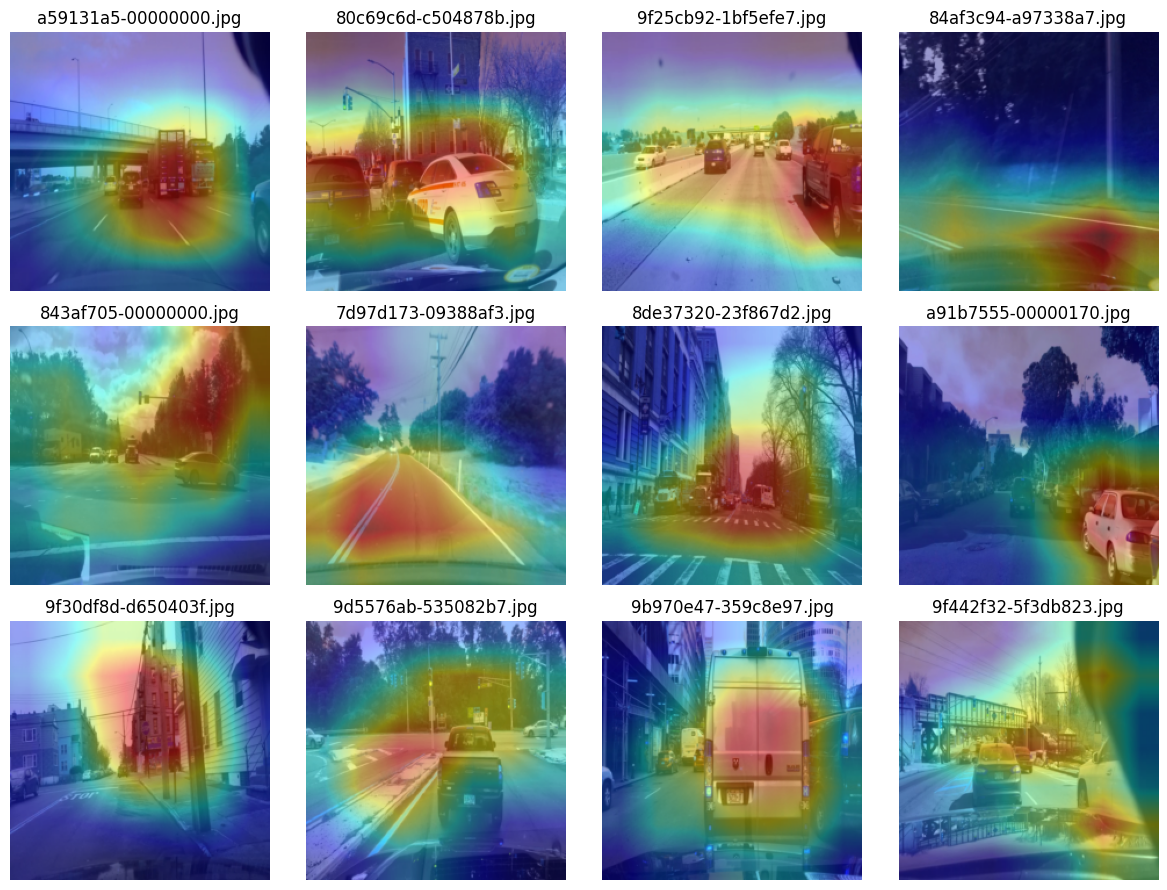

In [10]:
# Run Grad-CAM on N images and save overlays
N = min(12, len(dataset))
fig, axes = plt.subplots(nrows=N//4 + int(N%4>0), ncols=4, figsize=(12, 3*(N//4 + int(N%4>0))))
axes = np.array(axes).reshape(-1)
for i in range(N):
    img_t, path = dataset[i]
    inp = img_t.unsqueeze(0).to(device)
    heatmap = cam.generate(inp)
    # Convert back to uint8 image for overlay
    img_np = img_t.permute(1,2,0).cpu().numpy()
    img_np = (img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
    img_np = np.clip(img_np, 0, 1)
    overlay = overlay_heatmap((img_np*255).astype(np.uint8), heatmap)
    out_path = out_dir / f'gradcam_{i}.jpg'
    import imageio
    imageio.imwrite(out_path, overlay)
    axes[i].imshow(overlay)
    axes[i].set_title(Path(path).name)
    axes[i].axis('off')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()